<a href="https://colab.research.google.com/github/SastaGhost/data-analytics-project/blob/main/Modal_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [20]:
from google.colab import files
uploaded = files.upload()

Saving Diwali Sales Data.csv to Diwali Sales Data.csv


In [10]:
df = pd.read_csv("Diwali Sales Data.csv", encoding='latin1')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [11]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [12]:
df = df.drop(['Status','unnamed1'], axis=1, errors='ignore')
df.dropna(inplace=True)
df['Amount'] = df['Amount'].astype(int)

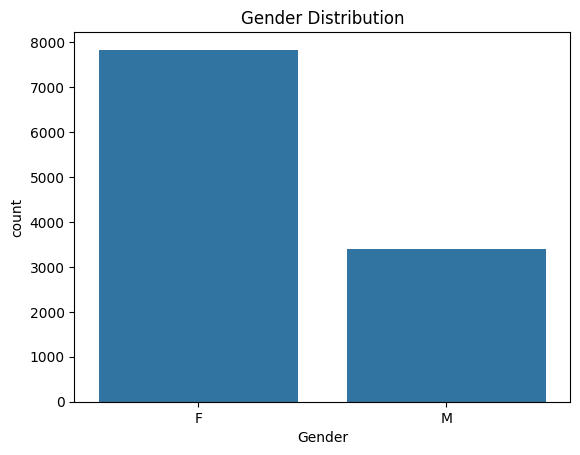

In [13]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

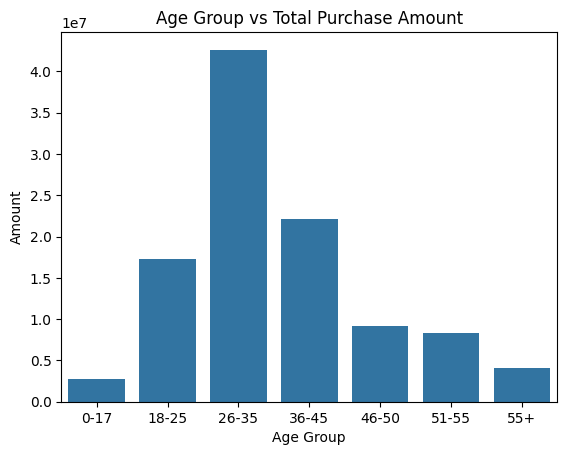

In [14]:
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum()

sns.barplot(x='Age Group', y='Amount', data=sales_age)
plt.title("Age Group vs Total Purchase Amount")
plt.show()

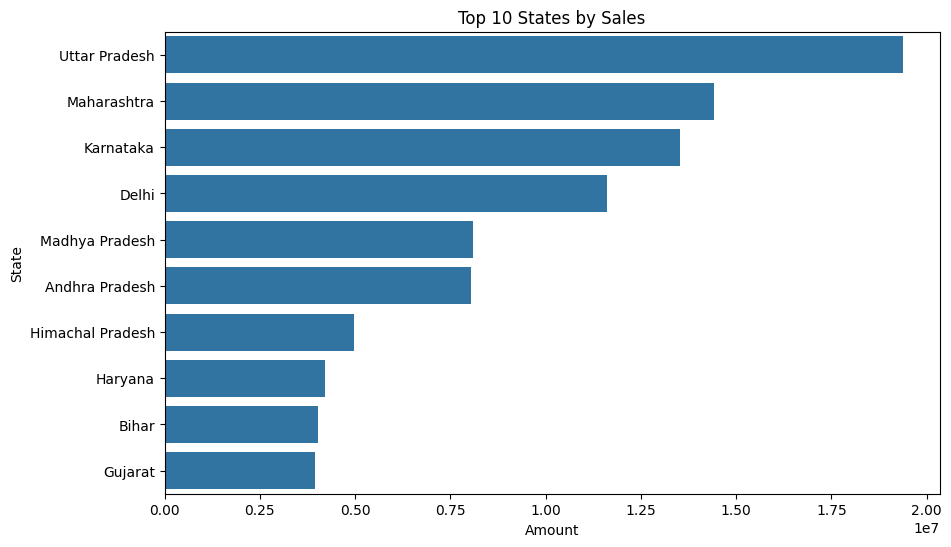

In [15]:
state_sales = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Amount', y='State', data=state_sales.head(10))
plt.title("Top 10 States by Sales")
plt.show()

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop("Amount", axis=1)
y = df_encoded["Amount"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2 Score:", baseline_r2)

Baseline RMSE: 4028.680684750714
Baseline R2 Score: 0.4037106837125589


In [21]:
from sklearn.ensemble import RandomForestRegressor
improved_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

improved_model.fit(X_train, y_train)

improved_pred = improved_model.predict(X_test)

improved_rmse = np.sqrt(mean_squared_error(y_test, improved_pred))
improved_r2 = r2_score(y_test, improved_pred)

print("Improved RMSE:", improved_rmse)
print("Improved R2 Score:", improved_r2)

Improved RMSE: 3598.4219484079554
Improved R2 Score: 0.5242755095969618


In [22]:
results = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)", "Random Forest (Improved)"],
    "RMSE": [baseline_rmse, improved_rmse],
    "R2 Score": [baseline_r2, improved_r2]
})

results

,Model,RMSE,R2 Score
0,Linear Regression (Baseline),4028.680685,0.403711
1,Random Forest (Improved),3598.421948,0.524276


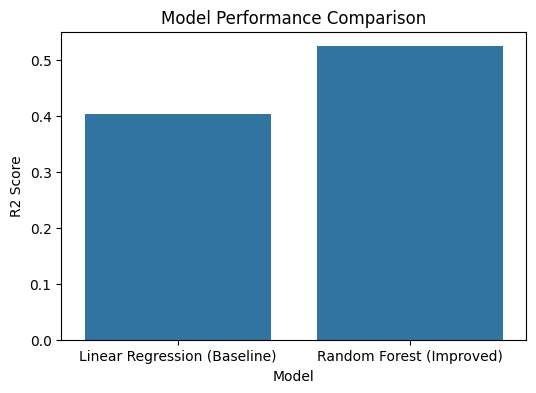

In [23]:
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Performance Comparison")
plt.show()

In [24]:
print("Insights:")
print("1. Random Forest performs better because it captures complex patterns.")
print("2. Linear Regression works as a baseline model.")
print("3. Ensemble methods improve prediction accuracy.")

Insights:
1. Random Forest performs better because it captures complex patterns.
2. Linear Regression works as a baseline model.
3. Ensemble methods improve prediction accuracy.
